Задача: по событиям куки за сутки выдать score от 0 до 1. Метрика - Precision при Recall >= 0.7, считаю её из `metric.py`

## Кратко о решении

**Очистка событий.** Оставляю только события внутри окна куки (в train около 17% событий лежат после конца окна, это утечка из будущего), убираю полные дубли строк (их число оставляю как признак), сортирую события по времени, привожу `platform` к трём значениям: web / android / ios.

**Признаки (133 шт.)** считаются только по событиям окна:
- курсор (только web): передаётся ли вообще, шаг между позициями, доля событий у края экрана;
- ритм: интервалы между событиями, сессии, пики за минуту и за 10 минут, насколько интервалы однообразные;
- разнообразие: города, категории, запросы, листание выдачи, повторы объявлений;
- типы событий и переходы между ними;
- возраст куки, доли семейств user-agent и платформ (сам UA строкой не беру).

**Валидация.** Основная — по времени, т.к. test идёт позже train: 5 фолдов по 2 дня, обучаюсь только на днях до фолда. Дополнительно — RepeatedStratifiedKFold 5×3: во временном фолде в среднем ~130 ботов, метрика сильно шумит, и нужно видеть разброс.

**Модель.** Среднее рангов: 0.5 × LightGBM (усреднение 3 сидов) + 0.5 × CatBoost.

**Результаты (P@R >= 0.7):**

| модель | по времени | random 5×3 |
|---|---|---|
| константа | 0.081 | 0.081 |
| RF из quickstart (2 признака) | 0.099 | 0.099 |
| LogReg | 0.704 | 0.754 |
| LightGBM, базовые параметры | 0.767 | 0.814 |
| **ансамбль LightGBM + CatBoost** | **0.775 ± 0.035** | **0.823 ± 0.044** |

**Содержание:** 
1. Данные и EDA  
2. Очистка событий 
3. Признаки 
4. Валидация 
5. Baseline и сравнение моделей 
6. Подбор параметров и группы признаков 
7. Ансамбль 
8. Финальная модель и submission 
9. Выводы

**Как запустить:** Python 3.11, `pip install -r requirements.txt`. Долгие эксперименты (сетка параметров, абляции) выключены флагом `RUN_LONG`, их результаты из моих прогонов записаны в markdown рядом.

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

from metric import precision_at_recall

SEED = 42
RUN_LONG = True  # True - запустить сетку параметров (долго)
pd.set_option("display.max_columns", 50)

## 1. Данные и EDA

In [3]:
dt_cols = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv("data/train.csv", parse_dates=dt_cols)
test = pd.read_csv("data/test.csv", parse_dates=dt_cols)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

print(train.shape, test.shape, events.shape)
print("доля ботов в train:", round(train.target.mean(), 4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [4]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [5]:
print(events.event_name.value_counts(), "\n")
print("пропуски:")
print(events.isna().mean().round(3))

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

пропуски:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


Пропуски структурные: `item_*` заполнены только у событий с объявлением, `search_*` — только у просмотров выдачи, курсор есть только у части событий (ниже видно, что только у web).

train: 2026-04-06 - 2026-04-19
test:  2026-04-20 - 2026-04-26


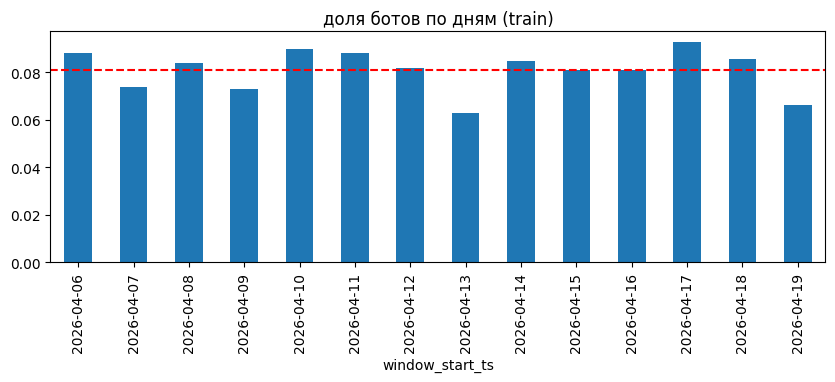

In [6]:
print("train:", train.window_start_ts.min().date(), "-", train.window_start_ts.max().date())
print("test: ", test.window_start_ts.min().date(), "-", test.window_start_ts.max().date())

by_day = train.groupby(train.window_start_ts.dt.date).target.mean()
by_day.plot(kind="bar", figsize=(10, 3), title="доля ботов по дням (train)")
plt.axhline(train.target.mean(), color="red", ls="--")
plt.show()

Ботов ~8%, по дням доля гуляет в пределах 6–9% без явного тренда. Test — следующая неделя (20–26.04), поэтому валидироваться буду по времени.

### Что не так с файлом событий

In [7]:
# события вне окна наблюдения
for name, meta in [("train", train), ("test", test)]:
    e = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id")
    before = (e.event_ts < e.window_start_ts).mean()
    after = (e.event_ts >= e.window_end_ts).mean()
    print(f"{name}: событий до окна {before:.1%}, после окна {after:.1%}")

train: событий до окна 0.0%, после окна 17.0%
test: событий до окна 0.0%, после окна 0.0%


In [8]:
print("полных дублей строк:", events.duplicated().sum())

# идут ли события куки по времени
sorted_share = events.groupby("cookie_id").event_ts.apply(lambda s: s.is_monotonic_increasing).mean()
print("доля кук, у которых события отсортированы по времени:", round(sorted_share, 3))

полных дублей строк: 4863
доля кук, у которых события отсортированы по времени: 0.035


In [9]:
print(events.platform.value_counts(), "\n")
print("сколько разных написаний platform у одной куки:")
print(events.groupby("cookie_id").platform.nunique().value_counts())

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

сколько разных написаний platform у одной куки:
platform
3    7144
4    7100
2    1312
1     444
Name: count, dtype: int64


Выводы по сырым событиям:
1. в train примерно 17% событий лежат **после** конца окна, в test таких нет. Признаки должны быть доступны на момент конца окна, поэтому эти события выкидываю, иначе даталик;
2. 4 863 полных дубля строк;
3. события не отсортированы по времени, для интервалов нужно сортировать;
4. `platform` записан в 11 вариантах (web/WEB/Web/desktop...), причём у большинства кук их 3–4 одновременно, то есть регистр случайный. Привожу к web / android / ios.

## 2. Очистка событий

In [10]:
EVENT_TYPES = ["search_results_view", "item_view", "photo_swipe", "seller_page_view",
               "contact_phone_show", "contact_chat_open", "contact_message_sent",
               "favorite_add", "login", "captcha_shown"]
CONTACTS = ["contact_phone_show", "contact_chat_open", "contact_message_sent"]
PLATFORMS = {"desktop": "web", "web": "web", "android": "android", "ios": "ios", "iphone": "ios"}


def clean_events(events, meta):
    ev = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id")
    # только события внутри окна
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)].copy()
    # дубли пока только помечаем: их количество пойдёт в признаки
    ev["is_dup"] = ev.duplicated(subset=list(events.columns), keep="first")
    ev["platform"] = ev.platform.str.lower().map(PLATFORMS)
    ev = ev.sort_values(["cookie_id", "event_ts", "eid"], kind="mergesort").reset_index(drop=True)
    return ev


def entropy(cnt):
    p = cnt[cnt > 0] / cnt.sum()
    return float(-(p * np.log(p)).sum()) if len(p) else 0.0


def ua_family(ua):
    # грубое семейство user-agent, сам UA строкой не используем
    if ua.startswith("Avito/"):
        return "app"
    for key, fam in [("HeadlessChrome", "headless"), ("python", "script"), ("curl", "script"),
                     ("Scrapy", "script"), ("Go-http", "script"), ("node-fetch", "script")]:
        if key in ua:
            return fam
    return "browser"

In [11]:
ev = clean_events(events, train).merge(train[["cookie_id", "target"]], on="cookie_id")

# доля ботов у кук с дублями и без
dups = ev.groupby("cookie_id").agg(n_dup=("is_dup", "sum"), target=("target", "first"))
print(dups.groupby(dups.n_dup > 0).target.agg(["mean", "size"]), "\n")

ev = ev[~ev.is_dup]
print(ev.platform.value_counts())

           mean  size
n_dup                
False  0.069981  8731
True   0.122034  2360 

platform
web        108382
android     76826
ios         10276
Name: count, dtype: int64


У кук с дублями доля ботов 12% против 7% у остальных, так что сами дубли выбрасываю, а их число и долю сохраняю как признаки.

### Чем боты отличаются от людей

Смотрю на очищенных событиях train.

In [12]:
# курсор
print("доля событий с курсором по платформам:")
print(ev.groupby("platform").pointer_x.apply(lambda s: s.notna().mean()), "\n")

web = ev[ev.platform == "web"]
print("web: доля событий с курсором (0 - люди, 1 - боты):")
print(web.groupby("target").pointer_x.apply(lambda s: s.notna().mean()), "\n")

w = web.dropna(subset=["pointer_x"]).copy()
w["step"] = np.hypot(w.groupby("cookie_id").pointer_x.diff(), w.groupby("cookie_id").pointer_y.diff())
w["edge"] = (w.pointer_x <= 0) | (w.pointer_x >= 1920) | (w.pointer_y <= 0) | (w.pointer_y >= 1080)
print(w.groupby("target").agg(step_median=("step", "median"), edge_share=("edge", "mean")))

доля событий с курсором по платформам:
platform
android    0.000000
ios        0.000000
web        0.602342
Name: pointer_x, dtype: float64 

web: доля событий с курсором (0 - люди, 1 - боты):
target
0    0.661829
1    0.330109
Name: pointer_x, dtype: float64 

        step_median  edge_share
target                         
0        744.887575    0.002412
1        278.152836    0.077774


Курсор есть **только у web**. У ботов на web он передаётся в два раза реже (33% событий против 66% у людей). Когда передаётся, ведёт себя иначе: медианный шаг между позициями ~280 px против ~745 px у людей (похоже на случайное блуждание), и в ~8% событий курсор упирается в край экрана 1920×1080, у людей — 0.2%.

медианный интервал, сек:
target
0    47.0
1    14.0
Name: dt, dtype: float64


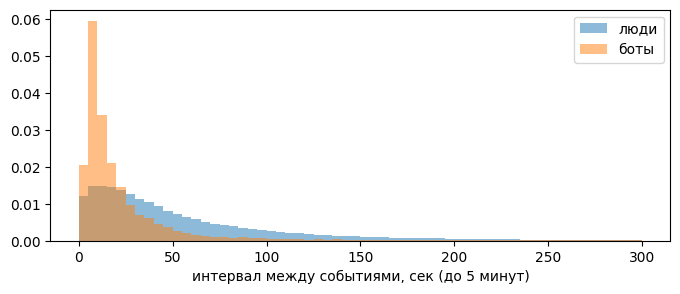

In [13]:
# ритм: интервалы между соседними событиями куки
ev["dt"] = ev.groupby("cookie_id").event_ts.diff().dt.total_seconds()
print("медианный интервал, сек:")
print(ev.groupby("target").dt.median())

fig, ax = plt.subplots(figsize=(8, 3))
for t, label in [(0, "люди"), (1, "боты")]:
    d = ev.loc[(ev.target == t) & (ev.dt <= 300), "dt"]
    ax.hist(d, bins=60, density=True, alpha=0.5, label=label)
ax.set_xlabel("интервал между событиями, сек (до 5 минут)")
ax.legend()
plt.show()

In [14]:
# user-agent: доля ботов по семействам (по кукам)
ev["ua"] = ev.user_agent.map(ua_family)
ua = ev.groupby(["cookie_id", "ua"]).target.first().reset_index()
print(ua.groupby("ua").target.agg(["mean", "size"]), "\n")

# возраст куки на начало окна, дни
age = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400
print("возраст куки, медиана:", age.groupby(train.target).median().round(1).to_dict())
print("возраст куки, 25% квантиль:", age.groupby(train.target).quantile(0.25).round(1).to_dict(), "\n")

per_cookie = ev.groupby("cookie_id").agg(n=("event_ts", "size"), n_loc=("item_location", "nunique"),
                                         target=("target", "first"))
print(per_cookie.groupby("target")[["n", "n_loc"]].agg(["median", "mean"]).round(1))

              mean  size
ua                      
app       0.092013  2141
browser   0.068880  8464
headless  0.262238   286
script    0.220000   200 

возраст куки, медиана: {0: 61.8, 1: 19.0}
возраст куки, 25% квантиль: {0: 18.9, 1: 0.9} 

            n        n_loc     
       median  mean median mean
target                         
0        12.0  16.6    5.0  5.9
1        20.0  29.0    8.0  9.8


Выводы:
1. ритм: медианный интервал у ботов 14 с против 47 с у людей, у ботов интервалы сильно сконцентрированы в нескольких секундах;
2. user-agent: явно «ботовые» UA (HeadlessChrome, curl, python и т.п.) в разметке в основном у **людей** — ботов среди таких кук 22–26%. Поэтому сырой UA как признак не беру (это техническая характеристика, а не поведение), оставляю только доли семейств;
3. возраст куки: у ботов куки сильно моложе (медиана ~19 дней против ~62 у людей, у четверти ботов кука младше суток);
4. разнообразие: боты делают больше событий и ходят по большему числу городов.

## 3. Признаки

Все признаки считаются по очищенным событиям окна, по одной строке на куку. Группы:
- типы событий: количества, доли, отношения к числу просмотров объявлений, переходы между типами;
- контент: уникальные объявления, категории, города, запросы, глубина и «последовательность» листания выдачи, перебор id подряд;
- курсор: доля событий с курсором (отдельно для web), разброс, шаг, доля у края экрана;
- ритм: интервалы, их однообразие, сессии (разрыв > 30 мин), интервалы внутри сессий, пики активности, часы;
- технические: доли семейств UA и платформ;
- дубли и возраст куки.

In [15]:
def timing_feats(ts):
    # ts - отсортированные времена событий куки в секундах
    n = len(ts)
    f = {}
    d = np.diff(ts) if n > 1 else np.array([])
    f["span_min"] = (ts[-1] - ts[0]) / 60 if n > 1 else 0.0
    if len(d):
        f["dt_mean"], f["dt_std"], f["dt_med"] = d.mean(), d.std(), np.median(d)
        f["dt_min"], f["dt_max"] = d.min(), d.max()
        f["dt_cv"] = d.std() / (d.mean() + 1e-9)
        f["dt_zero_share"] = (d == 0).mean()
        f["dt_le2_share"] = (d <= 2).mean()
        f["dt_le10_share"] = (d <= 10).mean()
        # насколько интервалы однообразные
        _, cnt = np.unique(d, return_counts=True)
        f["dt_mode_share"] = cnt.max() / len(d)
        f["dt_nunique_ratio"] = len(cnt) / len(d)
        f["dt_entropy"] = entropy(np.histogram(np.log1p(d), bins=12, range=(0, 12))[0].astype(float))
        f["dt_q10"], f["dt_q90"] = np.quantile(d, 0.1), np.quantile(d, 0.9)
        dd = np.abs(np.diff(d)) if len(d) > 1 else np.array([0.0])
        f["ddt_mean"] = dd.mean()
        f["ddt_rel"] = dd.mean() / (d.mean() + 1e-9)

    # сессии: разрыв больше 30 минут
    n_breaks = (d > 1800).sum() if len(d) else 0
    f["n_sessions"] = n_breaks + 1
    f["events_per_session"] = n / f["n_sessions"]

    # интервалы внутри сессий (без длинных пауз): у ботов они кучкуются в 3-10 c
    d_in = d[d <= 1800] if len(d) else d
    if len(d_in):
        logd = np.log1p(d_in)
        f["ws_dt_mean"], f["ws_dt_med"], f["ws_dt_std"] = d_in.mean(), np.median(d_in), d_in.std()
        f["ws_logdt_mean"], f["ws_logdt_std"] = logd.mean(), logd.std()
        f["ws_dt_iqr_ratio"] = (np.quantile(d_in, .75) - np.quantile(d_in, .25)) / (np.median(d_in) + 1)
        for lo, hi in [(0, 1), (2, 2), (3, 10), (11, 30), (31, 120), (121, 1800)]:
            f[f"ws_dt_bin_{lo}_{hi}"] = ((d_in >= lo) & (d_in <= hi)).mean()
        f["ws_n_intervals"] = len(d_in)
    f["session_len_max_min"] = 0.0
    if len(d):
        starts = np.r_[0, np.where(d > 1800)[0] + 1]
        ends = np.r_[np.where(d > 1800)[0], n - 1]
        lens = (ts[ends] - ts[starts]) / 60
        f["session_len_max_min"] = lens.max()
        f["session_len_mean_min"] = lens.mean()
        f["active_time_share"] = lens.sum() / (f["span_min"] + 1e-9) if f["span_min"] > 0 else 1.0

    # пики активности
    _, per_min = np.unique((ts // 60).astype(np.int64), return_counts=True)
    f["max_per_min"] = per_min.max()
    f["active_minutes"] = len(per_min)
    f["events_per_active_min"] = n / len(per_min)
    _, per_10min = np.unique(ts // 600, return_counts=True)
    f["max_per_10min"] = per_10min.max()

    hours = ((ts % 86400) // 3600).astype(int)
    hour_cnt = np.bincount(hours, minlength=24).astype(float)
    f["n_hours"] = (hour_cnt > 0).sum()
    f["hour_entropy"] = entropy(hour_cnt)
    f["night_share"] = hour_cnt[0:6].sum() / n
    f["first_hour"] = hours[0]
    f["mean_hour"] = hours.mean()
    return f

In [16]:
def cookie_feats(g):
    f = {}
    n = len(g)
    f["n_events"] = n
    names = g.event_name.values
    for e in EVENT_TYPES:
        c = (names == e).sum()
        f[f"cnt_{e}"] = c
        f[f"share_{e}"] = c / n
    f["n_event_types"] = len(set(names))
    f["cnt_contact"] = sum(f[f"cnt_{e}"] for e in CONTACTS)
    n_items = max(f["cnt_item_view"], 1)
    f["photo_per_item"] = f["cnt_photo_swipe"] / n_items
    f["contact_per_item"] = f["cnt_contact"] / n_items
    f["fav_per_item"] = f["cnt_favorite_add"] / n_items
    f["seller_per_item"] = f["cnt_seller_page_view"] / n_items
    f["search_per_item"] = f["cnt_search_results_view"] / n_items
    f["event_type_entropy"] = entropy(pd.Series(names).value_counts().values.astype(float))
    # переходы между типами событий: насколько повторяется один и тот же паттерн
    if n > 1:
        pairs = pd.Series(names[:-1]) + ">" + pd.Series(names[1:])
        vc = pairs.value_counts()
        f["trans_nunique_ratio"] = len(vc) / (n - 1)
        f["trans_top_share"] = vc.iloc[0] / (n - 1)
        f["same_type_repeat_share"] = (names[:-1] == names[1:]).mean()

    # разнообразие контента
    items = g.item_id.dropna()
    f["item_nunique"] = items.nunique()
    f["item_repeat_ratio"] = len(items) / max(items.nunique(), 1)
    f["item_unique_per_event"] = items.nunique() / n
    for col in ["item_category", "item_location", "search_query"]:
        s = g[col].dropna()
        f[f"{col}_nunique"] = s.nunique()
        f[f"{col}_top_share"] = s.value_counts(normalize=True).iloc[0] if len(s) else np.nan
    loc = g.item_location.dropna()
    f["loc_entropy"] = entropy(loc.value_counts().values.astype(float)) if len(loc) else 0.0
    cat = g.item_category.dropna()
    f["cat_entropy"] = entropy(cat.value_counts().values.astype(float)) if len(cat) else 0.0
    st = g.seller_type.dropna()
    f["pro_seller_share"] = (st == "pro").mean() if len(st) else np.nan

    pages = g.search_page.dropna().values
    if len(pages):
        f["page_max"], f["page_mean"] = pages.max(), pages.mean()
        f["page_gt1_share"] = (pages > 1).mean()
        f["page_nunique"] = len(np.unique(pages))
        # листание выдачи подряд 1, 2, 3, ... - похоже на краулер
        f["page_step1_share"] = (np.diff(pages) == 1).mean() if len(pages) > 1 else 0.0
    q = g.search_query.dropna()
    if len(q):
        f["query_len_mean"] = q.str.len().mean()
        f["query_repeat_ratio"] = len(q) / q.nunique()
    # перебор id объявлений подряд
    it = items.values
    if len(it) > 1:
        di = np.diff(it)
        f["item_id_step_small_share"] = (np.abs(di) <= 5).mean()
        f["item_id_monotonic_share"] = (di > 0).mean()

    # курсор
    px, py = g.pointer_x.values, g.pointer_y.values
    has = ~np.isnan(px)
    f["pointer_share"] = has.mean()
    if has.sum():
        xs, ys = px[has], py[has]
        f["pointer_x_std"], f["pointer_y_std"] = xs.std(), ys.std()
        f["pointer_unique_ratio"] = len(set(zip(xs, ys))) / has.sum()
        f["pointer_zero_share"] = ((xs == 0) & (ys == 0)).mean()
        f["pointer_x_mean"], f["pointer_y_mean"] = xs.mean(), ys.mean()
        f["pointer_round_share"] = ((xs % 10 == 0) & (ys % 10 == 0)).mean()
        # у ботов курсор "прилипает" к краям экрана 1920x1080
        f["pointer_edge_share"] = ((xs <= 0) | (xs >= 1920) | (ys <= 0) | (ys >= 1080)).mean()
        f["pointer_center_dist"] = np.hypot(xs - 960, ys - 540).mean()
        f["pointer_x_range"], f["pointer_y_range"] = np.ptp(xs), np.ptp(ys)
        if has.sum() > 1:
            step = np.hypot(np.diff(xs), np.diff(ys))
            f["pointer_step_mean"], f["pointer_step_med"] = step.mean(), np.median(step)
            f["pointer_step_max"] = step.max()
            f["pointer_small_step_share"] = (step < 300).mean()
    # у мобильных курсора нет вообще, поэтому отдельно считаем долю по web-событиям
    is_web = g.platform.values == "web"
    f["pointer_share_web"] = has[is_web].mean() if is_web.sum() else np.nan
    f["web_events_no_pointer"] = (is_web & ~has).sum()

    # действие с тем же объявлением, что и в прошлом событии (связность воронки)
    iid = g.item_id.values
    actions = np.isin(names, ["photo_swipe", "seller_page_view", "favorite_add"] + CONTACTS) & ~np.isnan(iid)
    if actions.sum():
        prev_item = pd.Series(iid).ffill().shift(1).values
        f["action_same_prev_item"] = (iid[actions] == prev_item[actions]).mean()
    if len(pages):
        f["pages_per_query"] = len(pages) / max(q.nunique(), 1)
    f["loc_per_item_event"] = f["item_location_nunique"] / max(len(g.item_location.dropna()), 1)

    # технические: доли семейств UA и платформ
    plat = g.platform.values
    f["tech_n_ua"] = g.user_agent.nunique()
    fams = g.user_agent.map(ua_family)
    for fam in ["app", "headless", "script", "browser"]:
        f[f"tech_ua_{fam}"] = (fams == fam).mean()
    for p in ["web", "android", "ios"]:
        f[f"tech_plat_{p}"] = (plat == p).mean()
    f["tech_n_platforms"] = len(set(plat))

    ts = g.event_ts.values.astype("datetime64[s]").astype(np.int64)
    f.update(timing_feats(ts))
    return f

In [17]:
def make_features(meta, events):
    ev = clean_events(events, meta)
    n_dup = ev.groupby("cookie_id").is_dup.sum().rename("n_dup_events")
    ev = ev[~ev.is_dup]

    rows = {cid: cookie_feats(g) for cid, g in ev.groupby("cookie_id", sort=False)}
    F = pd.DataFrame.from_dict(rows, orient="index")
    F.index.name = "cookie_id"
    F = F.join(n_dup)
    F["dup_share"] = F.n_dup_events / (F.n_events + F.n_dup_events)

    df = meta[["cookie_id", "cookie_created_at", "window_start_ts"]].merge(F.reset_index(), on="cookie_id", how="left")
    # возраст куки на начало окна (известен на момент конца окна)
    df["cookie_age_days"] = (df.window_start_ts - df.cookie_created_at).dt.total_seconds() / 86400
    df["created_in_window"] = (df.cookie_age_days < 0).astype(int)
    first_ev = ev.groupby("cookie_id").event_ts.min()
    df["created_to_first_event_min"] = (df.cookie_id.map(first_ev) - df.cookie_created_at).dt.total_seconds() / 60
    df["created_hour"] = df.cookie_created_at.dt.hour
    return df.drop(columns=["cookie_created_at", "window_start_ts"])

In [20]:
%%time
X_train = make_features(train, events)
X_test = make_features(test, events)
X_test = X_te[X_tr.columns]  # тот же порядок колонок, что и в train

assert (X_train.cookie_id.values == train.cookie_id.values).all()
assert (X_test.cookie_id.values == test.cookie_id.values).all()

feats = [c for c in X_train.columns if c != "cookie_id"]
y = train.target.values
print(X_train.shape, X_test.shape, "признаков:", len(feats))
print("из них технических (tech_):", sum(c.startswith("tech_") for c in feats))

(11091, 134) (4909, 134) признаков: 133
из них технических (tech_): 9
CPU times: user 40.4 s, sys: 535 ms, total: 41 s
Wall time: 41.6 s


In [21]:
X_train.head()

,cookie_id,n_events,cnt_search_results_view,share_search_results_view,cnt_item_view,share_item_view,cnt_photo_swipe,share_photo_swipe,cnt_seller_page_view,share_seller_page_view,cnt_contact_phone_show,share_contact_phone_show,cnt_contact_chat_open,share_contact_chat_open,cnt_contact_message_sent,share_contact_message_sent,cnt_favorite_add,share_favorite_add,cnt_login,share_login,cnt_captcha_shown,share_captcha_shown,n_event_types,cnt_contact,photo_per_item,...,ws_dt_bin_0_1,ws_dt_bin_2_2,ws_dt_bin_3_10,ws_dt_bin_11_30,ws_dt_bin_31_120,ws_dt_bin_121_1800,ws_n_intervals,session_len_max_min,session_len_mean_min,active_time_share,max_per_min,active_minutes,events_per_active_min,max_per_10min,n_hours,hour_entropy,night_share,first_hour,mean_hour,n_dup_events,dup_share,cookie_age_days,created_in_window,created_to_first_event_min,created_hour
0,ck_54a059eb7d3ea68b,7,3,0.428571,3,0.428571,1,0.142857,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.0,3,0,0.333333,...,0.166667,0.000000,0.166667,0.333333,0.333333,0.000000,6.0,2.783333,2.783333,1.000000,2,4,1.750000,7,1,-0.000000,1.00000,1,1.000000,0,0.000000,135.603692,0,195360.766667,9
1,ck_7e4de46eeab82974,41,8,0.195122,22,0.536585,4,0.097561,4,0.097561,1,0.024390,0,0.000000,0,0.000000,1,0.024390,1,0.024390,0,0.0,7,1,0.181818,...,0.000000,0.029412,0.205882,0.147059,0.617647,0.000000,34.0,9.650000,3.773810,0.040151,3,30,1.366667,12,8,1.857061,0.00000,10,14.829268,0,0.000000,194.576111,0,280840.033333,10
2,ck_9320229ef6304522,36,13,0.361111,7,0.194444,3,0.083333,3,0.083333,2,0.055556,1,0.027778,1,0.027778,3,0.083333,3,0.083333,0,0.0,9,4,0.428571,...,0.034483,0.000000,0.172414,0.517241,0.206897,0.068966,29.0,32.616667,5.752381,0.066208,4,21,1.714286,6,7,1.843821,0.50000,1,5.777778,0,0.000000,32.994421,0,47582.866667,0
3,ck_30ccd25bc1714ed9,21,3,0.142857,14,0.666667,0,0.000000,2,0.095238,1,0.047619,1,0.047619,0,0.000000,0,0.000000,0,0.000000,0,0.0,5,2,0.000000,...,0.000000,0.000000,0.055556,0.222222,0.722222,0.000000,18.0,6.833333,4.950000,0.051739,2,16,1.312500,7,3,0.998941,0.52381,2,4.666667,0,0.000000,0.546759,0,934.833333,10
4,ck_a77c5f05948cdeef,28,6,0.214286,12,0.428571,4,0.142857,3,0.107143,1,0.035714,0,0.000000,0,0.000000,2,0.071429,0,0.000000,0,0.0,6,1,0.333333,...,0.000000,0.000000,0.000000,0.208333,0.666667,0.125000,24.0,43.866667,13.229167,0.166248,2,25,1.120000,11,5,1.069000,0.00000,8,11.107143,1,0.034483,94.837095,0,137053.400000,3


NaN не заполняю: они осмысленные (например, у куки нет поиска → нет признаков выдачи), а бустинги умеют работать с пропусками сами. Для LogReg и RF пропуски заполняются внутри модели.

**Проверка сдвига train/test (adversarial validation).** Учу модель отличать train от test по признакам. Если AUC около 0.5 — распределения похожи.

In [22]:
Z = pd.concat([X_train[feats], X_test[feats]])
is_test = np.r_[np.zeros(len(X_tr)), np.ones(len(X_te))]

adv = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=42, verbose=-1)
p = cross_val_predict(adv, Z, is_test, cv=StratifiedKFold(5, shuffle=True, random_state=42), method="predict_proba")[:, 1]
print("adversarial AUC:", round(roc_auc_score(is_test, p), 4))

adversarial AUC: 0.4996


AUC примерно 0.5: по признакам train и test не различаются, сдвига нет. Значит random-фолды тоже можно использовать как дополнительную проверку.

## 4. Валидация

- **По времени** (основная): 5 фолдов по 2 дня (10–11, 12–13, 14–15, 16–17, 18–19 апреля), обучение только на днях до фолда.
- **RepeatedStratifiedKFold 5×3** (дополнительная): во временном фолде всего 94–161 бот, метрика шумная, поэтому смотрю ещё на 15 случайных фолдов, чтобы оценить разброс.
- Метрика — `precision_at_recall` из `metric.py`. Дополнительно смотрю ROC-AUC и PR-AUC по out-of-fold предсказаниям временных фолдов: они менее шумные.

In [23]:
day = train.window_start_ts
VAL_DAYS = [("2026-04-10", "2026-04-12"), ("2026-04-12", "2026-04-14"), ("2026-04-14", "2026-04-16"),
            ("2026-04-16", "2026-04-18"), ("2026-04-18", "2026-04-20")]

t_folds = []
for a, b in VAL_DAYS:
    idx_tr = np.where(day < a)[0]
    idx_va = np.where((day >= a) & (day < b))[0]
    t_folds.append((idx_tr, idx_va))

r_folds = list(RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED).split(np.zeros(len(y)), y))

for idx_tr, idx_va in t_folds:
    print(f"val {day[idx_va].min().date()} - {day[idx_va].max().date()}: "
          f"train {len(idx_tr)}, val {len(idx_va)}, ботов в val {y[idx_va].sum()}")

val 2026-04-10 - 2026-04-11: train 3305, val 1808, ботов в val 161
val 2026-04-12 - 2026-04-13: train 5113, val 1660, ботов в val 120
val 2026-04-14 - 2026-04-15: train 6773, val 1627, ботов в val 135
val 2026-04-16 - 2026-04-17: train 8400, val 1453, ботов в val 126
val 2026-04-18 - 2026-04-19: train 9853, val 1238, ботов в val 94


In [24]:
def run_cv(fit_predict, X, folds):
    scores = []
    oof = np.full(len(y), np.nan)
    for idx_tr, idx_va in folds:
        p = fit_predict(X.iloc[idx_tr], y[idx_tr], X.iloc[idx_va])
        scores.append(precision_at_recall(y[idx_va], p))
        oof[idx_va] = p
    return np.array(scores), oof


results = []
oofs = {}


def evaluate(name, fit_predict, cols=None):
    # обе схемы валидации + метрики по OOF временных фолдов
    X = X_train[feats if cols is None else cols]
    t_scores, oof = run_cv(fit_predict, X, t_folds)
    r_scores, _ = run_cv(fit_predict, X, r_folds)
    m = ~np.isnan(oof)  # первые дни (06-09.04) в валидацию не попадают
    res = {"model": name,
           "time": t_scores.mean(), "time_std": t_scores.std(),
           "pooled": precision_at_recall(y[m], oof[m]),
           "roc_auc": roc_auc_score(y[m], oof[m]),
           "pr_auc": average_precision_score(y[m], oof[m]),
           "random": r_scores.mean(), "random_std": r_scores.std(),
           "time_folds": t_scores.round(3)}
    results.append(res)
    oofs[name] = oof
    print(f"{name:34s} time={res['time']:.4f}±{res['time_std']:.3f} pooled={res['pooled']:.4f} "
          f"AUC={res['roc_auc']:.4f} PR-AUC={res['pr_auc']:.4f} | random={res['random']:.4f}±{res['random_std']:.3f}")
    return res

## 5. Baseline и сравнение моделей

- константа (уровень = доля ботов);
- RF из quickstart на двух признаках (`n_events`, `item_nunique`);
- LogReg на всех признаках;
- RandomForest, LightGBM и CatBoost на всех признаках.

In [25]:
def const(A, ya, B):
    return np.full(len(B), 0.5)


def rf_quickstart(A, ya, B):
    cols = ["n_events", "item_nunique"]
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
    return m.fit(A[cols], ya).predict_proba(B[cols])[:, 1]


def logreg(A, ya, B):
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegression(C=0.1, max_iter=3000))
    return m.fit(A, ya).predict_proba(B)[:, 1]


def rf(A, ya, B):
    imp = SimpleImputer(strategy="constant", fill_value=-1)
    m = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, max_features=0.3, random_state=SEED, n_jobs=2)
    return m.fit(imp.fit_transform(A), ya).predict_proba(imp.transform(B))[:, 1]


LGB_BASE = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=30,
                subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=1.0,
                random_state=SEED, verbose=-1, n_jobs=2)


def make_lgb(**params):
    p = {**LGB_BASE, **params}
    def fit_predict(A, ya, B):
        return lgb.LGBMClassifier(**p).fit(A, ya).predict_proba(B)[:, 1]
    return fit_predict


CAT_PARAMS = dict(iterations=800, learning_rate=0.05, depth=6, l2_leaf_reg=5,
                  random_seed=SEED, verbose=0, thread_count=2)


def catboost(A, ya, B):
    return CatBoostClassifier(**CAT_PARAMS).fit(A, ya).predict_proba(B)[:, 1]

In [26]:
%%time
evaluate("константа", const)
evaluate("RF quickstart (2 признака)", rf_quickstart)
evaluate("LogReg", logreg)
evaluate("RandomForest", rf)
evaluate("LightGBM (базовые параметры)", make_lgb())
evaluate("CatBoost", catboost);

константа                          time=0.0814±0.006 pooled=0.0817 AUC=0.5000 PR-AUC=0.0817 | random=0.0811±0.000
RF quickstart (2 признака)         time=0.0991±0.010 pooled=0.0974 AUC=0.6151 PR-AUC=0.2192 | random=0.0994±0.009
LogReg                             time=0.7044±0.045 pooled=0.7182 AUC=0.9314 PR-AUC=0.7583 | random=0.7541±0.058
RandomForest                       time=0.6768±0.027 pooled=0.6727 AUC=0.9174 PR-AUC=0.7508 | random=0.7362±0.073
LightGBM (базовые параметры)       time=0.7673±0.030 pooled=0.7508 AUC=0.9332 PR-AUC=0.7850 | random=0.8136±0.045
CatBoost                           time=0.7800±0.029 pooled=0.7688 AUC=0.9343 PR-AUC=0.7825 | random=0.8064±0.047
CPU times: user 18min 59s, sys: 12.7 s, total: 19min 12s
Wall time: 9min 43s


- Константа и RF из quickstart почти не отличаются от доли ботов (~0.08–0.10): двух счётчиков мало.
- На моих признаках уже LogReg даёт 0.704 по времени.
- Лучше всех бустинги: LightGBM 0.767, CatBoost 0.780 по времени. RandomForest заметно хуже (0.672).
- По random-CV числа выше, но и разброс между фолдами большой (std 0.04–0.07).
- XGBoost тоже пробовал (0.763 по времени), в ноутбук не включал: не лучше LightGBM/CatBoost.

## 6. Подбор параметров LightGBM и группы признаков

Небольшая сетка по `num_leaves`, `min_child_samples`, `colsample_bytree` (12 точек × 20 фолдов, поэтому под флагом).

In [27]:
grid = [dict(num_leaves=nl, min_child_samples=mc, colsample_bytree=cs)
        for nl in [7, 15, 31] for mc in [15, 40] for cs in [0.3, 0.6]]

if RUN_LONG:
    for params in grid:
        evaluate(f"LGBM {params}", make_lgb(**params))
else:
    print("RUN_LONG = False, сетку не запускаю (результаты ниже)")

LGBM {'num_leaves': 7, 'min_child_samples': 15, 'colsample_bytree': 0.3} time=0.7784±0.036 pooled=0.7650 AUC=0.9377 PR-AUC=0.7847 | random=0.7976±0.049
LGBM {'num_leaves': 7, 'min_child_samples': 15, 'colsample_bytree': 0.6} time=0.7611±0.017 pooled=0.7650 AUC=0.9358 PR-AUC=0.7815 | random=0.7965±0.051
LGBM {'num_leaves': 7, 'min_child_samples': 40, 'colsample_bytree': 0.3} time=0.7645±0.016 pooled=0.7624 AUC=0.9361 PR-AUC=0.7830 | random=0.7996±0.052
LGBM {'num_leaves': 7, 'min_child_samples': 40, 'colsample_bytree': 0.6} time=0.7587±0.020 pooled=0.7483 AUC=0.9357 PR-AUC=0.7811 | random=0.8016±0.045
LGBM {'num_leaves': 15, 'min_child_samples': 15, 'colsample_bytree': 0.3} time=0.7681±0.037 pooled=0.7611 AUC=0.9345 PR-AUC=0.7864 | random=0.8100±0.041
LGBM {'num_leaves': 15, 'min_child_samples': 15, 'colsample_bytree': 0.6} time=0.7736±0.019 pooled=0.7598 AUC=0.9333 PR-AUC=0.7860 | random=0.8114±0.047
LGBM {'num_leaves': 15, 'min_child_samples': 40, 'colsample_bytree': 0.3} time=0.7522±

Результаты моего прогона (P@R≥0.7, среднее = (по времени + random) / 2):

| num_leaves | min_child_samples | colsample_bytree | по времени | random | среднее |
|---|---|---|---|---|---|
| 7 | 15 | 0.3 | 0.7784 | 0.7976 | 0.7880 |
| 7 | 15 | 0.6 | 0.7611 | 0.7965 | 0.7788 |
| 7 | 40 | 0.3 | 0.7645 | 0.7996 | 0.7820 |
| 7 | 40 | 0.6 | 0.7587 | 0.8016 | 0.7802 |
| 15 | 15 | 0.3 | 0.7681 | 0.8100 | 0.7890 |
| 15 | 15 | 0.6 | 0.7736 | 0.8114 | 0.7925 |
| 15 | 40 | 0.3 | 0.7522 | 0.8152 | 0.7837 |
| 15 | 40 | 0.6 | 0.7583 | 0.8109 | 0.7846 |
| 31 | 15 | 0.3 | 0.7757 | 0.8154 | 0.7956 |
| 31 | 15 | 0.6 | 0.7718 | 0.8169 | 0.7943 |
| **31** | **40** | **0.3** | **0.7843** | 0.8140 | **0.7992** |
| 31 | 40 | 0.6 | 0.7644 | 0.8193 | 0.7919 |

Ландшафт плоский (среднее 0.779–0.799), так что сильно переобучиться под сетку не получится. Беру лучшую точку: `num_leaves=31, min_child_samples=40, colsample_bytree=0.3`.

In [28]:
BEST = dict(num_leaves=31, min_child_samples=40, colsample_bytree=0.3)
evaluate("LightGBM (подобранные параметры)", make_lgb(**BEST));

LightGBM (подобранные параметры)   time=0.7843±0.049 pooled=0.7676 AUC=0.9334 PR-AUC=0.7864 | random=0.8140±0.052


**Нужны ли все группы признаков?** Убираю по одной группе и смотрю на подобранном LightGBM. Плюс пробую оставить только top-k признаков по важности, посчитанной на днях до первого валидационного фолда (до 10.04), чтобы не подглядывать в валидацию.

In [29]:
TECH = [c for c in feats if c.startswith("tech_")]
V2 = [c for c in feats if c.startswith(("ws_", "session_len", "active_time_share",
                                        "action_same_prev_item", "pages_per_query", "loc_per_item_event"))]
AGE = ["cookie_age_days", "created_in_window", "created_to_first_event_min", "created_hour"]

if RUN_LONG:
    for name, group in [("без tech", TECH), ("без интервалов в сессиях и воронки", V2), ("без возраста куки", AGE)]:
        evaluate(name, make_lgb(**BEST), cols=[c for c in feats if c not in group])

    early = (day < "2026-04-10").values
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, random_state=SEED, verbose=-1,
                           importance_type="gain", **BEST).fit(X_train.loc[early, feats], y[early])
    order = pd.Series(m.feature_importances_, feats).sort_values(ascending=False).index.tolist()
    for k in [30, 50, 80]:
        evaluate(f"top-{k} по важности", make_lgb(**BEST), cols=order[:k])
else:
    print("RUN_LONG = False, абляции не запускаю (результаты ниже)")

без tech                           time=0.7719±0.046 pooled=0.7770 AUC=0.9326 PR-AUC=0.7837 | random=0.8014±0.057
без интервалов в сессиях и воронки time=0.7616±0.020 pooled=0.7663 AUC=0.9307 PR-AUC=0.7833 | random=0.8011±0.057
без возраста куки                  time=0.7516±0.025 pooled=0.7487 AUC=0.9333 PR-AUC=0.7818 | random=0.8079±0.055
top-30 по важности                 time=0.7088±0.031 pooled=0.6958 AUC=0.9325 PR-AUC=0.7643 | random=0.7515±0.055
top-50 по важности                 time=0.7316±0.023 pooled=0.7438 AUC=0.9317 PR-AUC=0.7761 | random=0.7767±0.052
top-80 по важности                 time=0.7635±0.045 pooled=0.7676 AUC=0.9330 PR-AUC=0.7798 | random=0.7985±0.050


## 7. Ансамбль

Усредняю ранги: LightGBM с подобранными параметрами (3 сида: 42, 7, 2024, предсказания усредняются) и CatBoost, веса 0.5 / 0.5. Ранги нужны, чтобы модели с разной калибровкой вероятностей вносили одинаковый вклад. Итоговый score получается в (0, 1].

In [36]:
def rank(p):
    return rankdata(p) / len(p)


def ensemble(A, ya, B):
    p_lgb = []
    for s in [42, 7, 2024]:
        m = lgb.LGBMClassifier(**{**LGB_BASE, **BEST, "random_state": s})
        p_lgb.append(rank(m.fit(A, ya).predict_proba(B)[:, 1]))
    p_cat = rank(catboost(A, ya, B))
    return 0.5 * np.mean(p_lgb, axis=0) + 0.5 * p_cat

In [31]:
%%time
res = evaluate("ансамбль", ensemble)
print("по фолдам времени:", res["time_folds"])

ансамбль                           time=0.7746±0.034 pooled=0.7784 AUC=0.9375 PR-AUC=0.7896 | random=0.8233±0.044
по фолдам времени: [0.748 0.784 0.792 0.824 0.725]
CPU times: user 4min 45s, sys: 17.6 s, total: 5min 3s
Wall time: 2min 48s


In [37]:
main = ["константа", "RF quickstart (2 признака)", "LogReg", "RandomForest", "LightGBM (базовые параметры)",
        "CatBoost", "LightGBM (подобранные параметры)", "ансамбль"]
table = pd.DataFrame(results).drop_duplicates("model", keep="last").set_index("model")
table = table.loc[main, ["time", "time_std", "pooled", "roc_auc", "pr_auc", "random", "random_std"]].astype(float).round(4)
table

,time,time_std,pooled,roc_auc,pr_auc,random,random_std
model,,,,,,,
константа,0.0814,0.0064,0.0817,0.5000,0.0817,0.0811,0.0002
RF quickstart (2 признака),0.0991,0.0098,0.0974,0.6151,0.2192,0.0994,0.0093
LogReg,0.7044,0.0449,0.7182,0.9314,0.7583,0.7541,0.0580
RandomForest,0.6768,0.0271,0.6727,0.9174,0.7508,0.7362,0.0731
LightGBM (базовые параметры),0.7673,0.0302,0.7508,0.9332,0.7850,0.8136,0.0451
CatBoost,0.7800,0.0289,0.7688,0.9343,0.7825,0.8064,0.0469
LightGBM (подобранные параметры),0.7843,0.0490,0.7676,0.9334,0.7864,0.8140,0.0520
ансамбль,0.7746,0.0345,0.7784,0.9375,0.7896,0.8233,0.0442


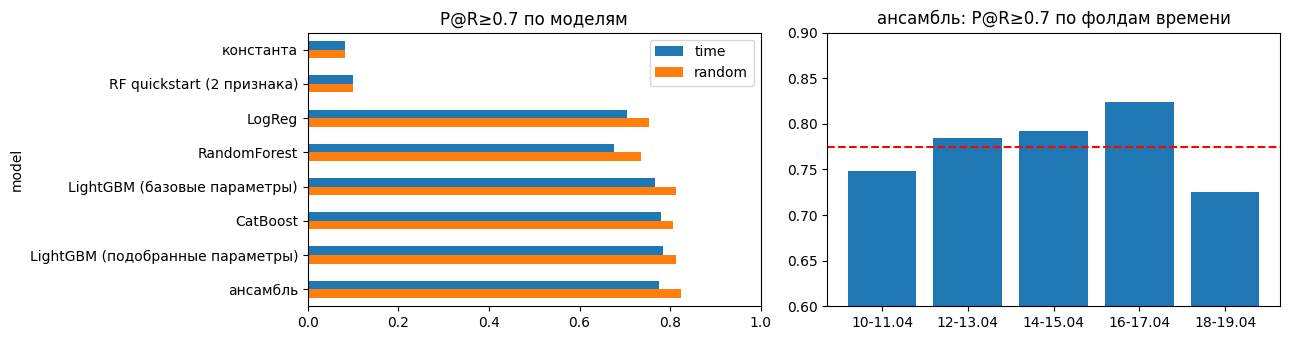

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

table[["time", "random"]].plot(kind="barh", ax=axes[0], xlim=(0, 1), title="P@R≥0.7 по моделям")
axes[0].invert_yaxis()

labels = ["10-11.04", "12-13.04", "14-15.04", "16-17.04", "18-19.04"]
axes[1].bar(labels, res["time_folds"])
axes[1].axhline(res["time"], color="red", ls="--")
axes[1].set_ylim(0.6, 0.9)
axes[1].set_title("ансамбль: P@R≥0.7 по фолдам времени")
plt.tight_layout()
plt.show()

- Ансамбль: **0.775 ± 0.035** по времени (pooled 0.778), **0.823 ± 0.044** на random-фолдах, ROC-AUC 0.938, PR-AUC 0.790.
- По random-CV, ROC-AUC и PR-AUC это лучший вариант. По времени одиночные CatBoost (0.780) и подобранный LightGBM (0.784) даже чуть выше, но разница меньше 0.01 при std ~0.03 — это шум. Ансамбль взял ради стабильности: в отдельном эксперименте у одного LightGBM смена сида двигала time-CV от 0.752 до 0.784, а усреднение сидов и двух разных бустингов это сглаживает.
- Time-CV ниже random, потому что в ранних фолдах модель учится всего на 4–10 днях, а финальная — на всех 14.
- Худший фолд — последний (18–19.04, 0.725), хотя обучающих данных там больше всего. При ~130 ботах на фолд это может быть шум, но это ближайшие к тесту дни.

**Качество по платформам.** Платформа куки — та, на которую приходится больше всего её событий.

In [39]:
plat = X_train[["tech_plat_web", "tech_plat_android", "tech_plat_ios"]].idxmax(axis=1).str.replace("tech_plat_", "")
oof = oofs["ансамбль"]
m = ~np.isnan(oof)

rows = []
for p in ["web", "android", "ios"]:
    mask = m & (plat == p).values
    rows.append({"platform": p, "кук": mask.sum(), "ботов": y[mask].sum(),
                 "PR-AUC": round(average_precision_score(y[mask], oof[mask]), 3)})
pd.DataFrame(rows)

,platform,кук,ботов,PR-AUC
0,web,4100,424,0.881
1,android,3293,195,0.603
2,ios,393,17,0.283


На web модель работает хорошо, на android заметно хуже, на iOS совсем плохо (там ещё и ботов мало, оценка шумная). У мобильных нет курсора, а это один из главных сигналов. Это основное слабое место решения.

## 8. Финальная модель и submission

Обучаю ансамбль на всём train (06–19.04) и предсказываю test.

In [42]:
%%time
score = ensemble(X_train[feats], y, X_test[feats])
sub = pd.DataFrame({"cookie_id": X_test.cookie_id.values, "score": score})

# проверки формата из условия
assert len(sub) == len(test) and sub.cookie_id.is_unique
assert set(sub.cookie_id) == set(test.cookie_id)
assert np.isfinite(sub.score).all() and sub.score.between(0, 1).all()

sub.to_csv("submission.csv", index=False)
print(sub.shape, "score от", sub.score.min().round(4), "до", sub.score.max().round(4),
      "| уникальных:", sub.score.nunique())
sub.head()

(4909, 2) score от 0.0018 до 0.9997 | уникальных: 4622
CPU times: user 16 s, sys: 960 ms, total: 17 s
Wall time: 9.51 s


,cookie_id,score
0,ck_315fb710a0e371e7,0.032627
1,ck_a76ee3b3e3e522fd,0.821416
2,ck_94c9a4d382689e82,0.858084
3,ck_8eaf9509ad9462a0,0.032831
4,ck_9a88a5a989cb5bc6,0.494534


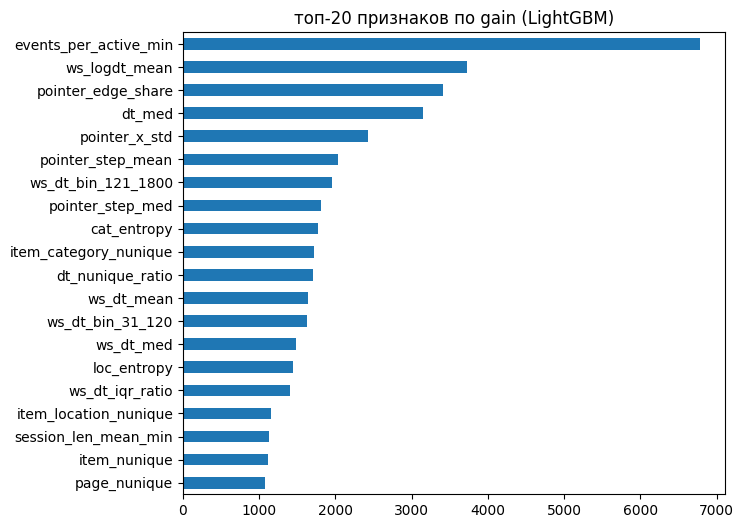

In [43]:
# на что смотрит модель (один LightGBM на всём train)
m = lgb.LGBMClassifier(**{**LGB_BASE, **BEST}, importance_type="gain").fit(X_train[feats], y)
imp = pd.Series(m.feature_importances_, feats).sort_values()
imp.tail(20).plot(kind="barh", figsize=(7, 6), title="топ-20 признаков по gain (LightGBM)")
plt.show()

## 9. Выводы

**Что сработало лучше всего**
1. **Курсор** (web): у ботов он чаще не передаётся, шаг между позициями почти в три раза меньше, чем у людей, и курсор чаще упирается в край экрана.
2. **Ритм событий**: медианный интервал у ботов 14 с против 47 с у людей; плюс пики активности, однообразие интервалов, интервалы внутри сессий.
3. **Разнообразие контента**: боты делают больше событий, ходят по большему числу городов и глубже листают выдачу.
4. **Возраст куки** и доли UA/платформ: небольшой, но стабильный прирост.

**Что ещё пробовал (в отдельных экспериментах)**

| идея | результат | взял? |
|---|---|---|
| новые признаки курсора (шаг, края экрана, доля web без курсора) | +0.037 по времени (0.730 → 0.767) | да |
| форма интервалов внутри сессий | одна почти ничего не даёт, но без неё −0.018 | да |
| доли семейств UA и платформ | +0.020 на 20 парных фолдах, 95% CI [+0.008; +0.032] | да |
| усреднение 3 сидов LightGBM | сглаживает разброс от сида (у одного LightGBM time-CV 0.752–0.784) | да |
| out-of-fold кодирование объявлений/запросов/городов (боты одного сервиса ходят по одним объявлениям) | без прироста | нет |
| «ботофермы»: плотность создания кук | 0.784 → 0.762 | нет |
| XGBoost | 0.763 по времени | нет |
| отбор top-k признаков | хуже полного набора | нет |

**Ограничения**
- Мобильные боты распознаются плохо: курсора нет, а часть пропущенных ботов по ритму и контенту не отличается от людей. Возможно, часть этой ошибки вообще неустранима или связана с шумом разметки.
- Метрика шумная (~130 ботов на фолд), поэтому различия меньше ~0.02 между вариантами не считаю значимыми.
- Признаки, параметры и ансамбль выбирались на тех же фолдах, по которым посчитана итоговая оценка, так что она может быть немного оптимистичной.
- Доли UA могут перестать работать, если сервисы сменят клиентские библиотеки. Основная сила модели — в поведенческих признаках.

**Что можно сделать дальше**
- разобрать пропущенных мобильных ботов и сделать признаки, которые считаются отдельно по мобильным событиям;
- посмотреть, на каких людях модель ошибается (ложные срабатывания);
- усреднить по сидам и CatBoost;
- проверить, не начало ли сдвига провал последнего фолда.